# Phân tích yếu tố thời gian và tỷ lệ chuyển đổi

**Câu hỏi nghiên cứu:** Các yếu tố thời gian trong dataset như **tháng truy cập**, **cuối tuần** và **mức độ gần ngày đặc biệt** có liên quan như thế nào đến **tỷ lệ chuyển đổi**?

Notebook này tập trung vào 3 biến thời gian trong bộ dữ liệu `online_shoppers_intention`: `Month`, `Weekend`, `SpecialDay`, và biến mục tiêu `Revenue`.

**Cách hiểu tỷ lệ chuyển đổi:**

\[
Conversion\ Rate = \frac{\text{Số phiên có Revenue = True}}{\text{Tổng số phiên truy cập}}
\]

**Lưu ý:** Phân tích này tìm mối liên hệ/thống kê mô tả, không khẳng định quan hệ nhân quả.

In [1]:
# Import thư viện
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2_contingency
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

%matplotlib inline

## 1. Đọc dữ liệu và kiểm tra nhanh

Ô dưới đây đọc file CSV. Khi chạy trên máy cá nhân, hãy đặt file `online_shoppers_intention(1).csv` cùng thư mục với notebook, hoặc sửa lại biến `DATA_PATH` cho đúng vị trí file của bạn.

In [2]:
# Đường dẫn dữ liệu
possible_paths = [
    Path('online_shoppers_intention(1).csv'),
    Path('online_shoppers_intention.csv'),
    Path('/mnt/data/online_shoppers_intention(1).csv')
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Không tìm thấy file CSV. Hãy đặt file online_shoppers_intention(1).csv cùng thư mục notebook hoặc sửa DATA_PATH.')

df = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu:', df.shape)
df.head()

Kích thước dữ liệu: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Kiểm tra kiểu dữ liệu và số lượng giá trị thiếu
info_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_rate_%': (df.isna().mean() * 100).round(2)
})
info_table

,dtype,missing_values,missing_rate_%
Administrative,int64,0,0.0000
Administrative_Duration,float64,0,0.0000
Informational,int64,0,0.0000
Informational_Duration,float64,0,0.0000
ProductRelated,int64,0,0.0000
ProductRelated_Duration,float64,0,0.0000
BounceRates,float64,0,0.0000
ExitRates,float64,0,0.0000
PageValues,float64,0,0.0000
SpecialDay,float64,0,0.0000


## 2. Chuẩn hóa biến mục tiêu và tạo bảng tổng quan

`Revenue=True` nghĩa là phiên truy cập có chuyển đổi thành giao dịch. Ta chuyển biến này sang dạng số để tính trung bình, vì trung bình của cột 0/1 chính là tỷ lệ chuyển đổi.

In [4]:
# Chuyển Revenue sang 0/1 để tính conversion rate
if df['Revenue'].dtype == bool:
    df['Revenue_num'] = df['Revenue'].astype(int)
else:
    df['Revenue_num'] = df['Revenue'].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype(int)

# Sắp xếp tháng theo thứ tự thời gian có trong dataset
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

overall_conversion_rate = df['Revenue_num'].mean()
summary_overall = pd.DataFrame({
    'Tổng số phiên': [len(df)],
    'Số phiên chuyển đổi': [df['Revenue_num'].sum()],
    'Tỷ lệ chuyển đổi': [overall_conversion_rate],
    'Tỷ lệ chuyển đổi (%)': [overall_conversion_rate * 100]
})
summary_overall

,Tổng số phiên,Số phiên chuyển đổi,Tỷ lệ chuyển đổi,Tỷ lệ chuyển đổi (%)
0,12330,1908,0.1547,15.4745


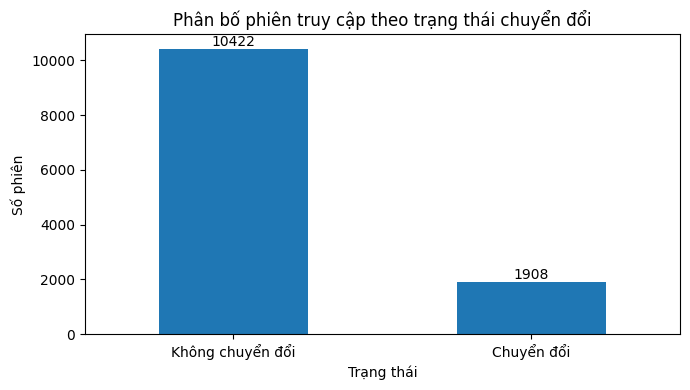

Tỷ lệ chuyển đổi chung: 15.47%


In [5]:
# Biểu đồ phân bố biến Revenue
revenue_counts = df['Revenue'].value_counts().sort_index()
revenue_counts.index = ['Không chuyển đổi', 'Chuyển đổi']

fig, ax = plt.subplots(figsize=(7, 4))
revenue_counts.plot(kind='bar', ax=ax)
ax.set_title('Phân bố phiên truy cập theo trạng thái chuyển đổi')
ax.set_xlabel('Trạng thái')
ax.set_ylabel('Số phiên')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Tỷ lệ chuyển đổi chung: {overall_conversion_rate:.2%}')

## 3. Tỷ lệ chuyển đổi theo tháng truy cập

Ta tính số phiên, số phiên chuyển đổi và tỷ lệ chuyển đổi theo từng tháng. Biểu đồ giúp so sánh cả **lưu lượng truy cập** và **hiệu quả chuyển đổi** theo mùa/tháng.

In [6]:
def conversion_summary(data, group_col):
    result = (
        data.groupby(group_col, observed=True)['Revenue_num']
        .agg(Sessions='count', Conversions='sum', Conversion_Rate='mean')
        .reset_index()
    )
    result['Conversion_Rate_%'] = result['Conversion_Rate'] * 100
    return result

month_summary = conversion_summary(df, 'Month')
month_summary

,Month,Sessions,Conversions,Conversion_Rate,Conversion_Rate_%
0,Feb,184,3,0.0163,1.6304
1,Mar,1907,192,0.1007,10.0682
2,May,3364,365,0.1085,10.8502
3,June,288,29,0.1007,10.0694
4,Jul,432,66,0.1528,15.2778
5,Aug,433,76,0.1755,17.5520
6,Sep,448,86,0.1920,19.1964
7,Oct,549,115,0.2095,20.9472
8,Nov,2998,760,0.2535,25.3502
9,Dec,1727,216,0.1251,12.5072


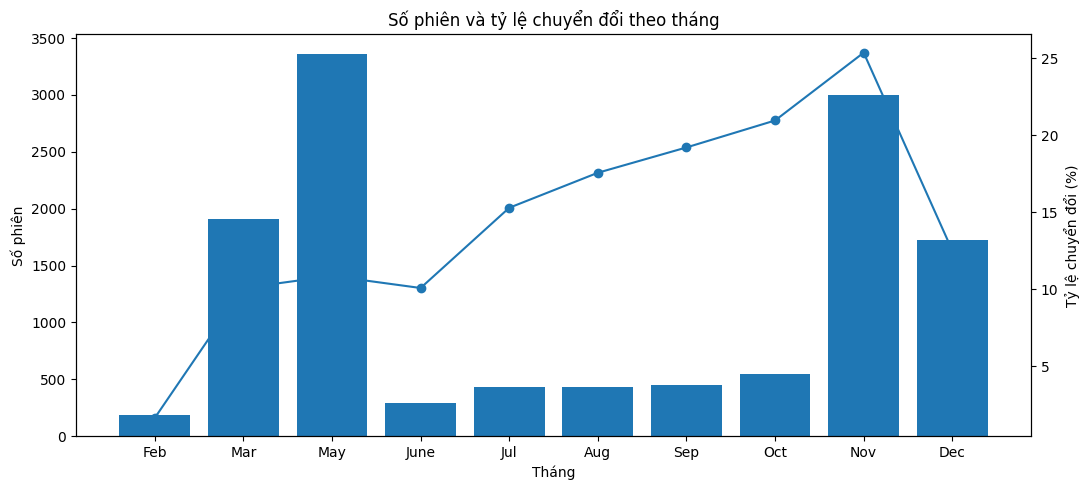

In [7]:
# Biểu đồ số phiên và tỷ lệ chuyển đổi theo tháng
fig, ax1 = plt.subplots(figsize=(11, 5))

x = np.arange(len(month_summary))
ax1.bar(x, month_summary['Sessions'], label='Số phiên')
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Số phiên')
ax1.set_xticks(x)
ax1.set_xticklabels(month_summary['Month'])

ax2 = ax1.twinx()
ax2.plot(x, month_summary['Conversion_Rate_%'], marker='o', label='Tỷ lệ chuyển đổi (%)')
ax2.set_ylabel('Tỷ lệ chuyển đổi (%)')

ax1.set_title('Số phiên và tỷ lệ chuyển đổi theo tháng')
fig.tight_layout()
plt.show()

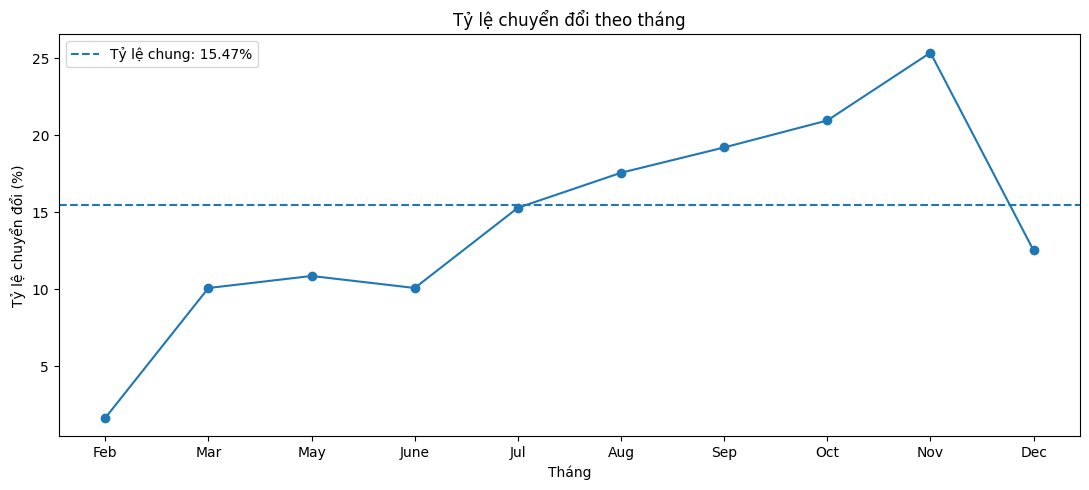

,Month,Sessions,Conversions,Conversion_Rate,Conversion_Rate_%
8,Nov,2998,760,0.2535,25.3502
7,Oct,549,115,0.2095,20.9472
6,Sep,448,86,0.1920,19.1964
5,Aug,433,76,0.1755,17.5520
4,Jul,432,66,0.1528,15.2778
9,Dec,1727,216,0.1251,12.5072
2,May,3364,365,0.1085,10.8502
3,June,288,29,0.1007,10.0694
1,Mar,1907,192,0.1007,10.0682
0,Feb,184,3,0.0163,1.6304


In [8]:
# Biểu đồ tập trung vào tỷ lệ chuyển đổi theo tháng
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(month_summary['Month'].astype(str), month_summary['Conversion_Rate_%'], marker='o')
ax.axhline(overall_conversion_rate * 100, linestyle='--', label=f'Tỷ lệ chung: {overall_conversion_rate*100:.2f}%')
ax.set_title('Tỷ lệ chuyển đổi theo tháng')
ax.set_xlabel('Tháng')
ax.set_ylabel('Tỷ lệ chuyển đổi (%)')
ax.legend()
plt.tight_layout()
plt.show()

month_summary.sort_values('Conversion_Rate_%', ascending=False)

**Nhận xét sơ bộ theo tháng:**

Tỷ lệ chuyển đổi thay đổi rõ theo tháng. Trong dữ liệu này, tháng 11 có tỷ lệ chuyển đổi cao nhất, sau đó là tháng 10 và tháng 9. Tháng 2 có tỷ lệ thấp nhất. Điều này gợi ý có yếu tố mùa vụ, đặc biệt giai đoạn cuối năm có xu hướng chuyển đổi tốt hơn.

## 4. Tỷ lệ chuyển đổi theo cuối tuần

Biến `Weekend` cho biết phiên truy cập có diễn ra vào cuối tuần hay không. Ta so sánh tỷ lệ chuyển đổi giữa ngày thường và cuối tuần.

In [9]:
weekend_summary = conversion_summary(df, 'Weekend')
weekend_summary['Weekend_Label'] = weekend_summary['Weekend'].map({False: 'Ngày thường', True: 'Cuối tuần'})
weekend_summary[['Weekend_Label', 'Sessions', 'Conversions', 'Conversion_Rate', 'Conversion_Rate_%']]

,Weekend_Label,Sessions,Conversions,Conversion_Rate,Conversion_Rate_%
0,Ngày thường,9462,1409,0.1489,14.8911
1,Cuối tuần,2868,499,0.1740,17.3989


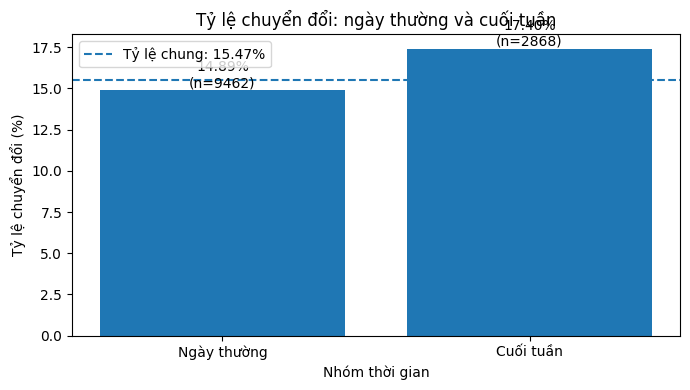

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weekend_summary['Weekend_Label'], weekend_summary['Conversion_Rate_%'])
ax.axhline(overall_conversion_rate * 100, linestyle='--', label=f'Tỷ lệ chung: {overall_conversion_rate*100:.2f}%')
ax.set_title('Tỷ lệ chuyển đổi: ngày thường và cuối tuần')
ax.set_xlabel('Nhóm thời gian')
ax.set_ylabel('Tỷ lệ chuyển đổi (%)')
ax.legend()

for i, row in weekend_summary.iterrows():
    ax.text(i, row['Conversion_Rate_%'], f"{row['Conversion_Rate_%']:.2f}%\n(n={row['Sessions']})", ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Nhận xét sơ bộ theo cuối tuần:**

Các phiên truy cập vào cuối tuần có tỷ lệ chuyển đổi cao hơn ngày thường. Tuy nhiên, chênh lệch không quá lớn, vì vậy cần xem thêm kiểm định thống kê và kích thước ảnh hưởng ở phần sau.

## 5. Tỷ lệ chuyển đổi theo mức độ gần ngày đặc biệt

`SpecialDay` là biến số từ 0 đến 1, thể hiện mức độ gần với một ngày đặc biệt. Giá trị càng cao nghĩa là phiên truy cập càng gần ngày đặc biệt. Ta xem tỷ lệ chuyển đổi thay đổi như thế nào khi `SpecialDay` tăng.

In [10]:
special_summary = conversion_summary(df, 'SpecialDay')
special_summary

,SpecialDay,Sessions,Conversions,Conversion_Rate,Conversion_Rate_%
0,0.0000,11079,1831,0.1653,16.5268
1,0.2000,178,14,0.0787,7.8652
2,0.4000,243,13,0.0535,5.3498
3,0.6000,351,29,0.0826,8.2621
4,0.8000,325,11,0.0338,3.3846
5,1.0000,154,10,0.0649,6.4935


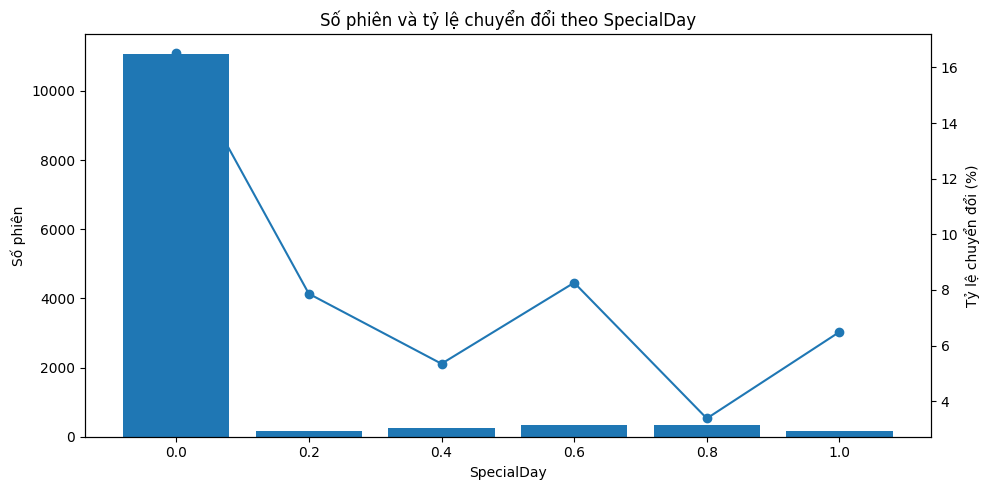

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(special_summary))
labels = special_summary['SpecialDay'].astype(str)

ax1.bar(x, special_summary['Sessions'], label='Số phiên')
ax1.set_xlabel('SpecialDay')
ax1.set_ylabel('Số phiên')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.plot(x, special_summary['Conversion_Rate_%'], marker='o', label='Tỷ lệ chuyển đổi (%)')
ax2.set_ylabel('Tỷ lệ chuyển đổi (%)')

ax1.set_title('Số phiên và tỷ lệ chuyển đổi theo SpecialDay')
fig.tight_layout()
plt.show()

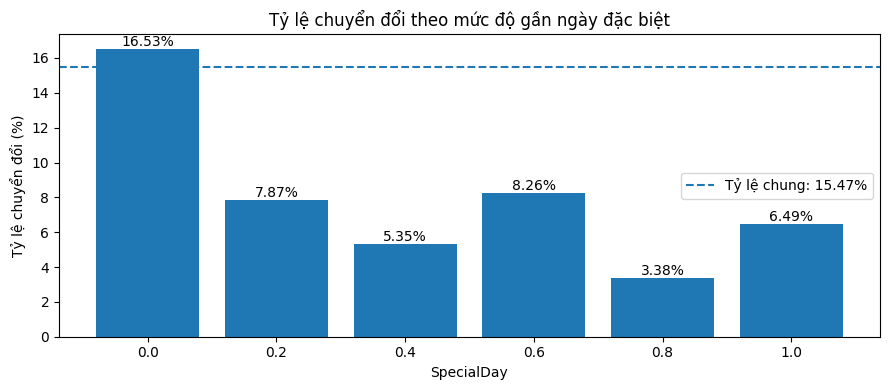

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(special_summary['SpecialDay'].astype(str), special_summary['Conversion_Rate_%'])
ax.axhline(overall_conversion_rate * 100, linestyle='--', label=f'Tỷ lệ chung: {overall_conversion_rate*100:.2f}%')
ax.set_title('Tỷ lệ chuyển đổi theo mức độ gần ngày đặc biệt')
ax.set_xlabel('SpecialDay')
ax.set_ylabel('Tỷ lệ chuyển đổi (%)')
ax.legend()

for i, row in special_summary.iterrows():
    ax.text(i, row['Conversion_Rate_%'], f"{row['Conversion_Rate_%']:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Nhận xét sơ bộ theo ngày đặc biệt:**

Trong dataset này, nhóm `SpecialDay = 0` có tỷ lệ chuyển đổi cao hơn các nhóm gần ngày đặc biệt. Các nhóm `SpecialDay > 0` có tỷ lệ chuyển đổi thấp hơn đáng kể. Điều này có thể gợi ý rằng người dùng gần ngày đặc biệt có thể vào xem/tham khảo nhiều hơn nhưng chưa chắc mua ngay, hoặc lượng mẫu ở các nhóm này nhỏ hơn nên tỷ lệ dao động mạnh hơn.

## 6. Kết hợp tháng và cuối tuần

Biểu đồ heatmap dưới đây cho thấy tỷ lệ chuyển đổi khi xét đồng thời tháng truy cập và trạng thái cuối tuần. Cách này giúp phát hiện xem cuối tuần có tác động nhất quán ở mọi tháng hay chỉ nổi bật ở một số tháng.

In [13]:
month_weekend_pivot = (
    pd.pivot_table(
        df,
        index='Month',
        columns='Weekend',
        values='Revenue_num',
        aggfunc='mean',
        observed=True
    ) * 100
)
month_weekend_pivot = month_weekend_pivot.rename(columns={False: 'Ngày thường', True: 'Cuối tuần'})
month_weekend_pivot

Weekend,Ngày thường,Cuối tuần
Month,,
Feb,1.2821,3.5714
Mar,8.9060,13.5135
May,10.0415,13.8462
June,9.9585,10.6383
Jul,15.2439,15.3846
Aug,18.9911,12.5000
Sep,18.1818,22.9167
Oct,20.9877,20.8333
Nov,24.9207,26.5487


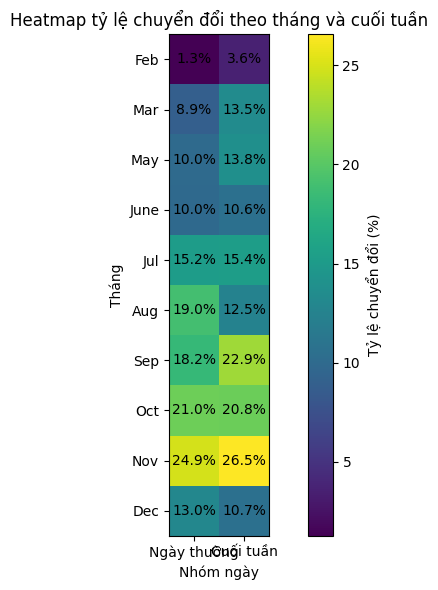

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(month_weekend_pivot.values)

ax.set_xticks(np.arange(month_weekend_pivot.shape[1]))
ax.set_xticklabels(month_weekend_pivot.columns)
ax.set_yticks(np.arange(month_weekend_pivot.shape[0]))
ax.set_yticklabels(month_weekend_pivot.index.astype(str))
ax.set_title('Heatmap tỷ lệ chuyển đổi theo tháng và cuối tuần')
ax.set_xlabel('Nhóm ngày')
ax.set_ylabel('Tháng')

for i in range(month_weekend_pivot.shape[0]):
    for j in range(month_weekend_pivot.shape[1]):
        value = month_weekend_pivot.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f'{value:.1f}%', ha='center', va='center')

fig.colorbar(im, ax=ax, label='Tỷ lệ chuyển đổi (%)')
plt.tight_layout()
plt.show()

**Nhận xét khi kết hợp tháng và cuối tuần:**

Hiệu ứng cuối tuần không hoàn toàn giống nhau ở tất cả các tháng. Một số tháng cuối tuần có tỷ lệ chuyển đổi cao hơn ngày thường, nhưng cũng có tháng ngược lại. Vì vậy, khi xây dựng mô hình dự đoán, nên giữ cả biến `Month` và `Weekend`, đồng thời có thể cân nhắc đặc trưng tương tác giữa hai biến này.

## 7. Kiểm định thống kê: các biến thời gian có liên quan đến Revenue không?

Vì `Revenue` là biến phân loại True/False, ta dùng kiểm định Chi-square để xem phân phối chuyển đổi có khác nhau đáng kể giữa các nhóm thời gian hay không.

Ngoài p-value, ta tính thêm **Cramér's V** để đo kích thước ảnh hưởng. Cách đọc tham khảo:

- Gần 0: liên hệ rất yếu.
- Khoảng 0.1: yếu.
- Khoảng 0.3: vừa.
- Khoảng 0.5 trở lên: mạnh.

In [15]:
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))

if SCIPY_AVAILABLE:
    stats_rows = []
    for col in ['Month', 'Weekend', 'SpecialDay']:
        table = pd.crosstab(df[col], df['Revenue'])
        chi2, p, dof, expected = chi2_contingency(table)
        stats_rows.append({
            'Biến thời gian': col,
            'Chi-square': chi2,
            'p-value': p,
            'df': dof,
            "Cramer's V": cramers_v(table)
        })

    stats_summary = pd.DataFrame(stats_rows)
    stats_summary
else:
    print('SciPy chưa được cài đặt, bỏ qua kiểm định Chi-square.')

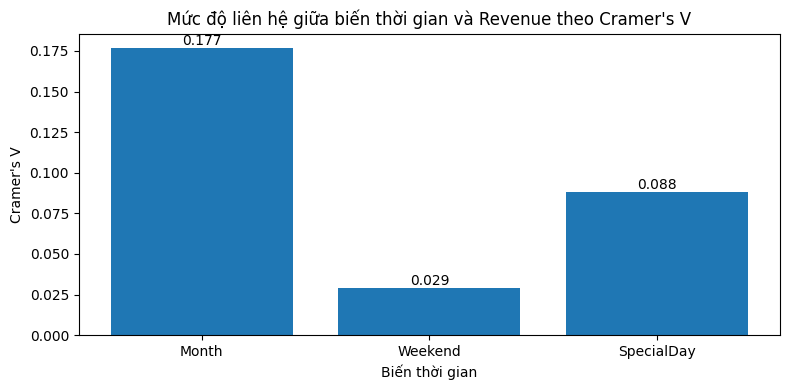

In [16]:
if SCIPY_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(stats_summary['Biến thời gian'], stats_summary["Cramer's V"])
    ax.set_title("Mức độ liên hệ giữa biến thời gian và Revenue theo Cramer's V")
    ax.set_xlabel('Biến thời gian')
    ax.set_ylabel("Cramer's V")
    for i, value in enumerate(stats_summary["Cramer's V"]):
        ax.text(i, value, f'{value:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

## 8. Tổng hợp kết luận cho báo cáo

Dựa trên dữ liệu và các biểu đồ ở trên, có thể trả lời câu hỏi nghiên cứu như sau:

1. **Tháng truy cập có liên quan rõ nhất đến tỷ lệ chuyển đổi.** Tỷ lệ chuyển đổi cao nhất rơi vào tháng 11, tiếp theo là tháng 10 và tháng 9. Các tháng đầu năm hoặc giữa năm như tháng 2, tháng 3, tháng 5, tháng 6 có tỷ lệ thấp hơn đáng kể. Điều này cho thấy yếu tố mùa vụ có thể ảnh hưởng đến hành vi mua hàng trực tuyến.

2. **Cuối tuần có tỷ lệ chuyển đổi cao hơn ngày thường, nhưng mức độ ảnh hưởng yếu.** Nhóm cuối tuần có tỷ lệ chuyển đổi nhỉnh hơn, tuy nhiên chênh lệch không lớn. Vì vậy, `Weekend` có thể hữu ích khi đưa vào mô hình, nhưng không nên xem là yếu tố quyết định mạnh.

3. **Mức độ gần ngày đặc biệt có xu hướng liên quan ngược với tỷ lệ chuyển đổi.** Trong dataset này, các phiên có `SpecialDay = 0` đạt tỷ lệ chuyển đổi cao hơn các nhóm gần ngày đặc biệt. Điều này có thể phản ánh việc người dùng gần ngày đặc biệt truy cập để tham khảo, so sánh hoặc tìm khuyến mãi nhưng không nhất thiết mua ngay.

4. **Kiểm định Chi-square cho thấy cả `Month`, `Weekend` và `SpecialDay` đều có liên hệ thống kê với `Revenue`, nhưng kích thước ảnh hưởng khác nhau.** Theo Cramér's V, `Month` có mức liên hệ lớn nhất trong ba yếu tố thời gian, `SpecialDay` yếu hơn, và `Weekend` là yếu nhất.

**Kết luận ngắn gọn:** Trong các yếu tố thời gian, **tháng truy cập** là biến có liên hệ đáng chú ý nhất với tỷ lệ chuyển đổi. **Cuối tuần** có tác động tích cực nhẹ, còn **gần ngày đặc biệt** trong dataset này lại đi kèm tỷ lệ chuyển đổi thấp hơn. Khi xây dựng mô hình dự đoán chuyển đổi, nên đưa cả ba biến vào, nhưng cần ưu tiên phân tích mùa vụ theo tháng.